In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objs as go
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

# Only Numeric Features

In [47]:
df = pd.read_csv('./ObesityDataSet_raw_and_data_sinthetic.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [49]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [50]:
df.columns = df.columns.str.strip()

/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: The palette list has more values (17) than needed (2), which may not be intended.
  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: 
The palette list has fe

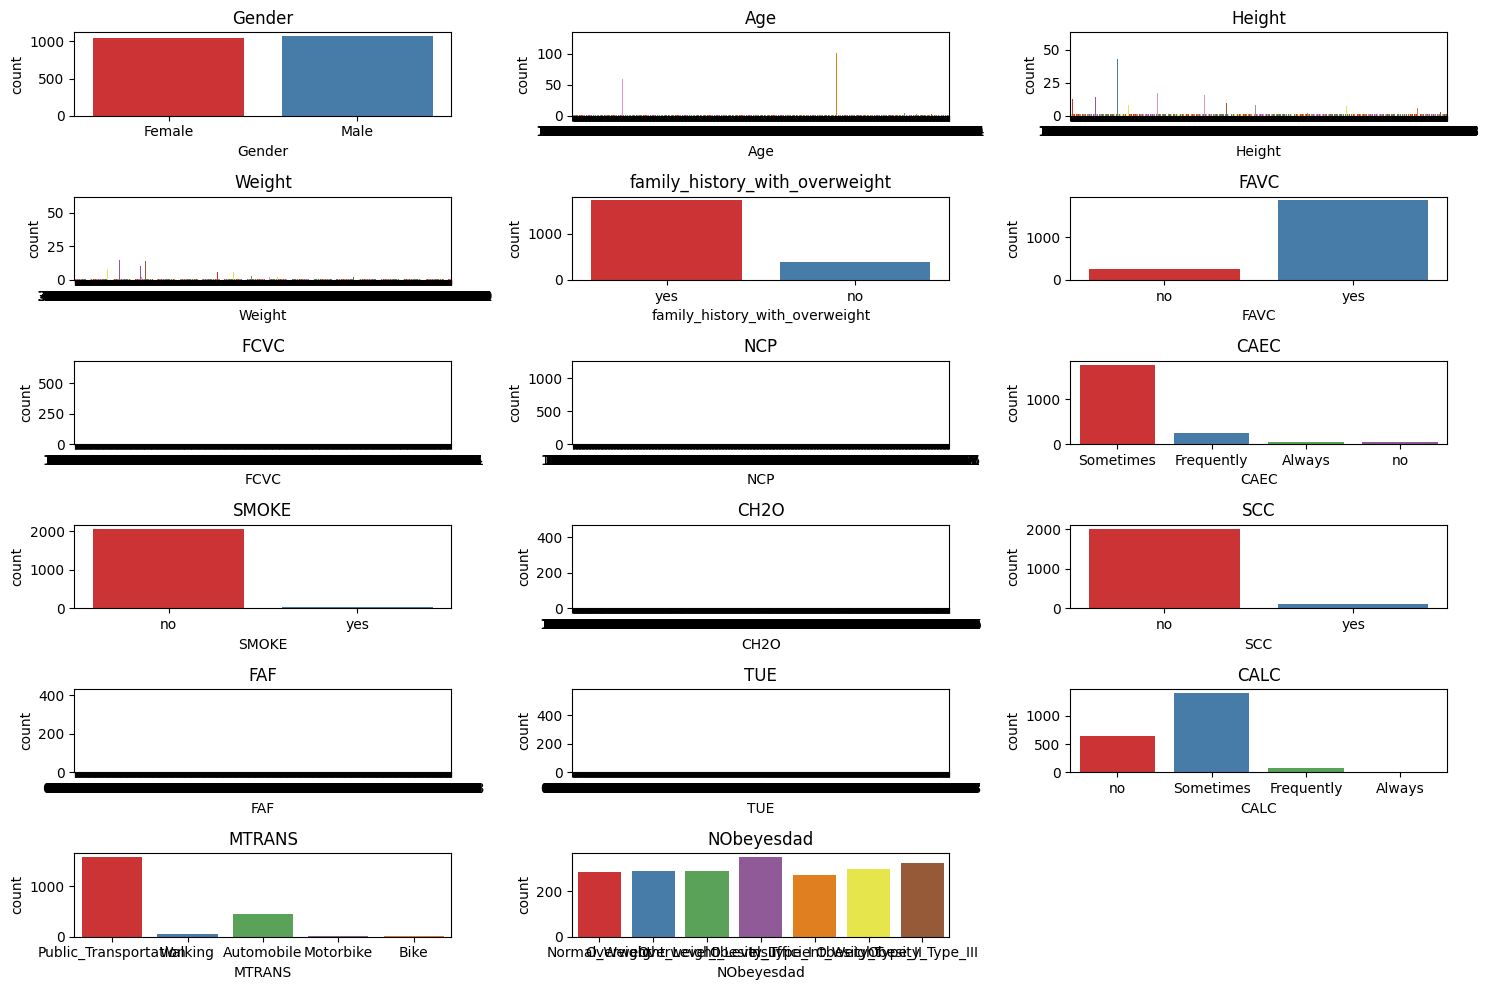

In [51]:
color_palette = sns.color_palette("Set1", len(df.columns))

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot((len(df.columns)//3)+1, 3, i)
    sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(column)

plt.tight_layout()
plt.show()

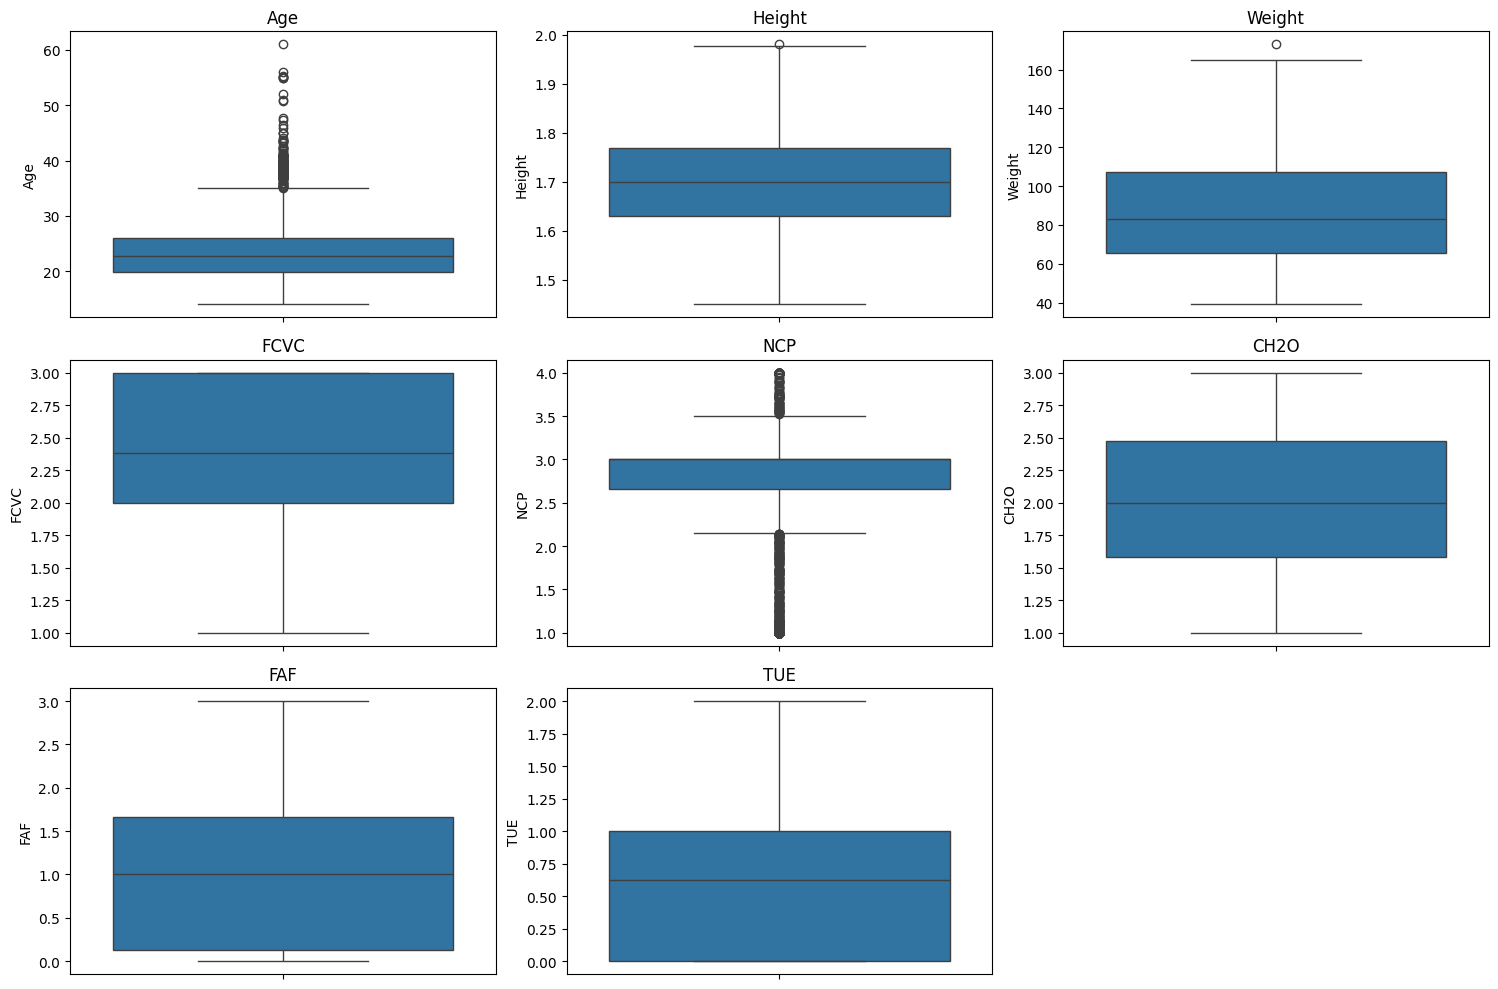

In [52]:
# select numerical columns
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)//3)+1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [55]:
cols = ['Weight', 'Height']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

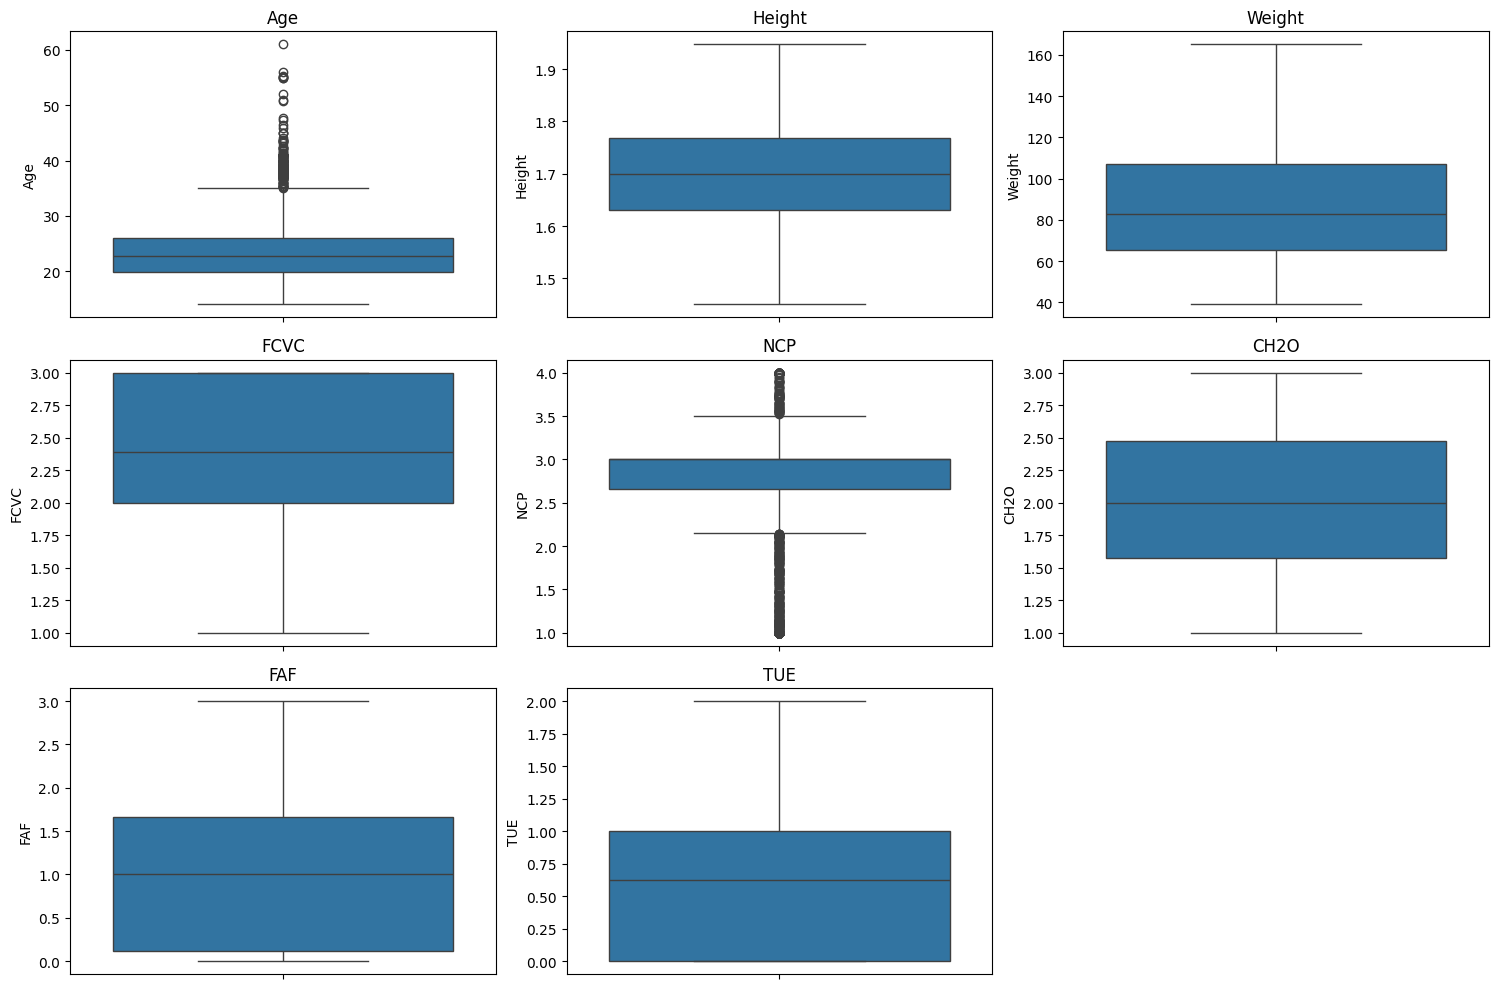

In [56]:
# select numerical columns
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)//3)+1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [57]:
df_train = df[num_cols]

## K-Means Clustering

In [58]:
wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [495750.9831287699]
silhoutte score for n_clusters = 2 is 0.5709700459356024
wcss score for n_cluster = 3 is [495750.9831287699, 274890.6704192239]
silhoutte score for n_clusters = 3 is 0.5068167088015718
wcss score for n_cluster = 4 is [495750.9831287699, 274890.6704192239, 191496.02256279177]
silhoutte score for n_clusters = 4 is 0.47886605631218315
wcss score for n_cluster = 5 is [495750.9831287699, 274890.6704192239, 191496.02256279177, 154086.72249908987]
silhoutte score for n_clusters = 5 is 0.4359595845147928
wcss score for n_cluster = 6 is [495750.9831287699, 274890.6704192239, 191496.02256279177, 154086.72249908987, 121200.67746372215]
silhoutte score for n_clusters = 6 is 0.46431244699614405
wcss score for n_cluster = 7 is [495750.9831287699, 274890.6704192239, 191496.02256279177, 154086.72249908987, 121200.67746372215, 95099.51908155315]
silhoutte score for n_clusters = 7 is 0.4526214336355736
wcss score for n_cluster = 8 is [495750.9831287699

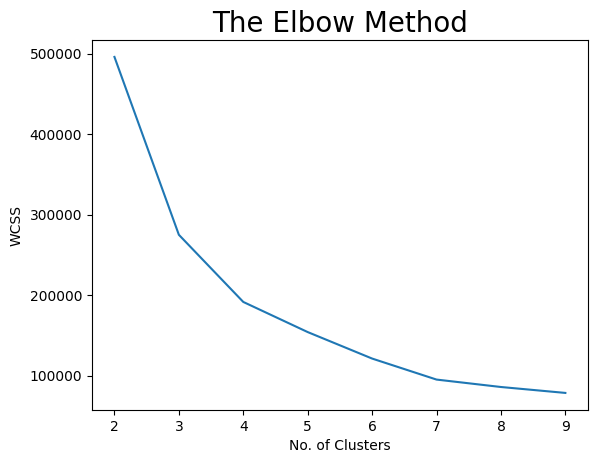

In [59]:
# Visualisasi Elbow Score
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

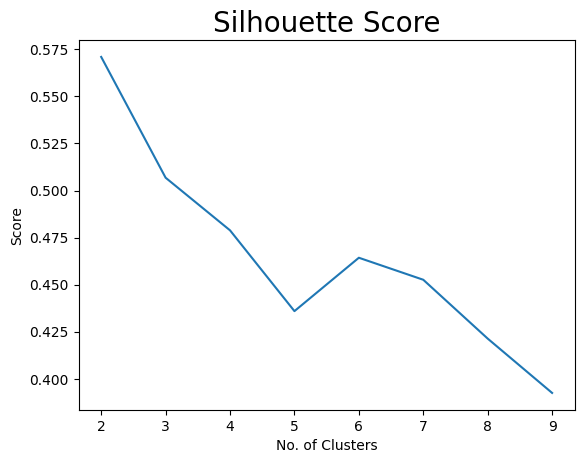

In [60]:
# Visualisasi Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [61]:
kmeansmodel = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

df_train['Cluster'] = y_kmeans

In [62]:
df_train[df_train['Cluster'] == 0].describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Cluster
count,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.0
mean,23.573199,1.674990,68.842237,2.322428,2.608619,1.943098,1.071110,0.667667,0.0
std,6.967184,0.091013,14.229117,0.533309,0.903802,0.609253,0.899749,0.653422,0.0
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0
25%,19.000000,1.605501,56.276224,2.000000,2.008204,1.510309,0.130031,0.000000,0.0
50%,21.085569,1.675529,70.000000,2.061422,3.000000,2.000000,1.000000,0.641145,0.0
75%,24.261370,1.740000,80.538174,2.941123,3.000000,2.197400,2.000000,1.000000,0.0
max,61.000000,1.930000,91.499683,3.000000,4.000000,3.000000,3.000000,2.000000,0.0


In [63]:
df_train[df_train['Cluster'] == 1].describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Cluster
count,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.0
mean,25.486950,1.742552,114.152492,2.570508,2.804959,2.107163,0.914262,0.641284,1.0
std,5.019657,0.080005,13.408302,0.499067,0.503321,0.604798,0.758995,0.532759,0.0
min,17.000000,1.560000,91.495718,1.000000,1.000000,1.000000,0.000000,0.000000,1.0
25%,21.697106,1.674682,104.790671,2.031610,3.000000,1.663950,0.112199,0.167402,1.0
50%,25.496168,1.752972,111.941263,2.871453,3.000000,2.137210,0.975904,0.617066,1.0
75%,26.947124,1.795956,120.994169,3.000000,3.000000,2.627254,1.484860,0.927822,1.0
max,41.000000,1.947406,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000,1.0


In [64]:
cluster_summary = df_train.groupby('Cluster').mean()
cluster_summary

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Cluster,,,,,,,,
0,23.573199,1.674990,68.842237,2.322428,2.608619,1.943098,1.071110,0.667667
1,25.486950,1.742552,114.152492,2.570508,2.804959,2.107163,0.914262,0.641284


## Hierarchical (Agglomerative) Clustering

In [65]:
from sklearn.cluster import AgglomerativeClustering

linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]
for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 10):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j]) # Menggunakan Ward Method
        AC.fit(df_train)

        labels = AC.labels_
        silhouette_avg = silhouette_score(df_train, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.571397432516545
silhoutte score for n_clusters = 3 is 0.49070060470241744
silhoutte score for n_clusters = 4 is 0.4748155376570704
silhoutte score for n_clusters = 5 is 0.45497192930420516
silhoutte score for n_clusters = 6 is 0.43700542605321413
silhoutte score for n_clusters = 7 is 0.41577945590407783
silhoutte score for n_clusters = 8 is 0.419876956559042
silhoutte score for n_clusters = 9 is 0.4285889621182144

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.571397432516545
silhoutte score for n_clusters = 3 is 0.512412201883323
silhoutte score for n_clusters = 4 is 0.46536347511532283
silhoutte score for n_clusters = 5 is 0.4235274647025388
silhoutte score for n_clusters = 6 is 0.38455981121951566
silhoutte score for n_clusters = 7 is 0.3814984404392492
silhoutte score for n_clusters = 8 is 0.38856996534077304
silhoutte score for n_clusters = 9 is 0.3828902806591919

#####################

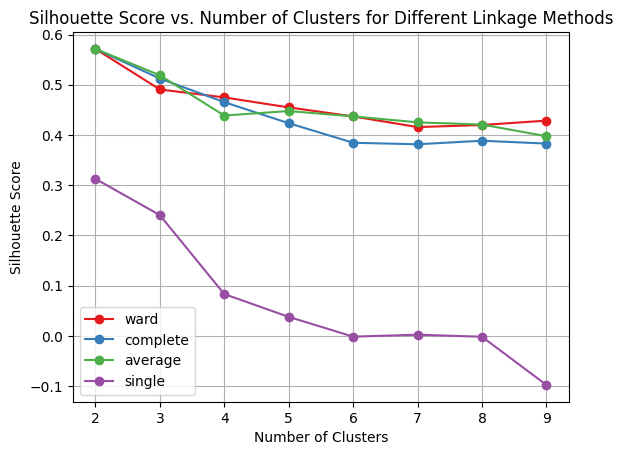

In [66]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 10), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
cluster = 2
AC = AgglomerativeClustering(n_clusters=cluster, linkage='average')
labels = AC.fit_predict(df_train)

df_train_with_labels = df_train.copy()

# Add cluster labels to the DataFrame
df_train_with_labels['Cluster'] = labels

# Summary for a specific cluster
print("Summary for Cluster 0:")
print(df_train_with_labels[df_train_with_labels['Cluster'] == 0].describe())

# Mean values for each cluster
cluster_summary = df_train_with_labels.groupby('Cluster').mean()
print("\nCluster-wise Mean Summary:")
print(cluster_summary)

Summary for Cluster 0:
              Age      Height      Weight        FCVC         NCP        CH2O  \
count  809.000000  809.000000  809.000000  809.000000  809.000000  809.000000   
mean    25.406904    1.741460  114.498325    2.579828    2.809582    2.112533   
std      4.948151    0.079936   13.232348    0.497410    0.498053    0.602596   
min     17.000000    1.560000   92.949254    1.000000    1.000000    1.000000   
25%     21.688557    1.670774  104.846218    2.046651    3.000000    1.679489   
50%     25.478662    1.751365  111.950413    2.902469    3.000000    2.145368   
75%     26.734476    1.792833  121.000000    3.000000    3.000000    2.627569   
max     41.000000    1.947406  165.057269    3.000000    4.000000    3.000000   

              FAF         TUE  Cluster  
count  809.000000  809.000000    809.0  
mean     0.914682    0.641224      0.0  
std      0.762889    0.533241      0.0  
min      0.000000    0.000000      0.0  
25%      0.109327    0.169016      0.0  
5

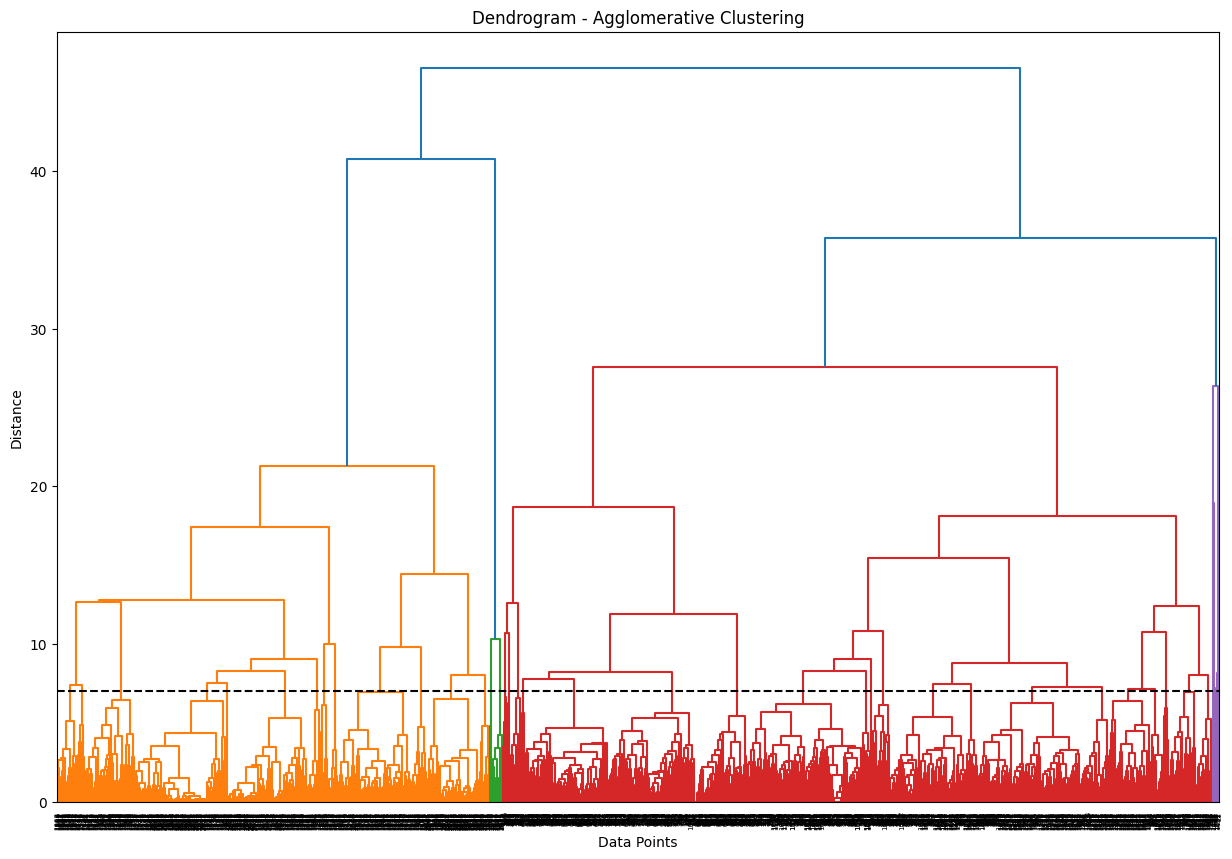

In [68]:
if 'Cluster' in df_train.columns:
    features = df_train.drop(columns=['Cluster']).values
else:
    features = df_train.values

# Generate the linkage matrix
linked = sch.linkage(features, method='average')  # average linkage

# Plot dendrogram
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False  # hide 2111 leaf labels for readability
)
plt.title('Dendrogram - Agglomerative Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')

# Optional: draw horizontal line to show cut (adjust depending on your data scale)
plt.axhline(y=7, color='black', linestyle='--')  # use scaled distance
plt.show()

# All Features

In [69]:
df = pd.read_csv('./ObesityDataSet_raw_and_data_sinthetic.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [71]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [72]:
df.columns = df.columns.str.strip()

# Convert True/False boolean columns to 1/0
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# Convert categorical/object columns to numeric codes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[cat_cols] = df[cat_cols].apply(lambda col: pd.Categorical(col).codes)

print(df.dtypes)
print(df.head())

Gender                               int8
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight       int8
FAVC                                 int8
FCVC                              float64
NCP                               float64
CAEC                                 int8
SMOKE                                int8
CH2O                              float64
SCC                                  int8
FAF                               float64
TUE                               float64
CALC                                 int8
MTRANS                               int8
NObeyesdad                           int8
dtype: object
   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0    

/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/3667412469.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: The palette list has more values (17) than needed (2), which may not be intended.
  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: 
The palette list has fe

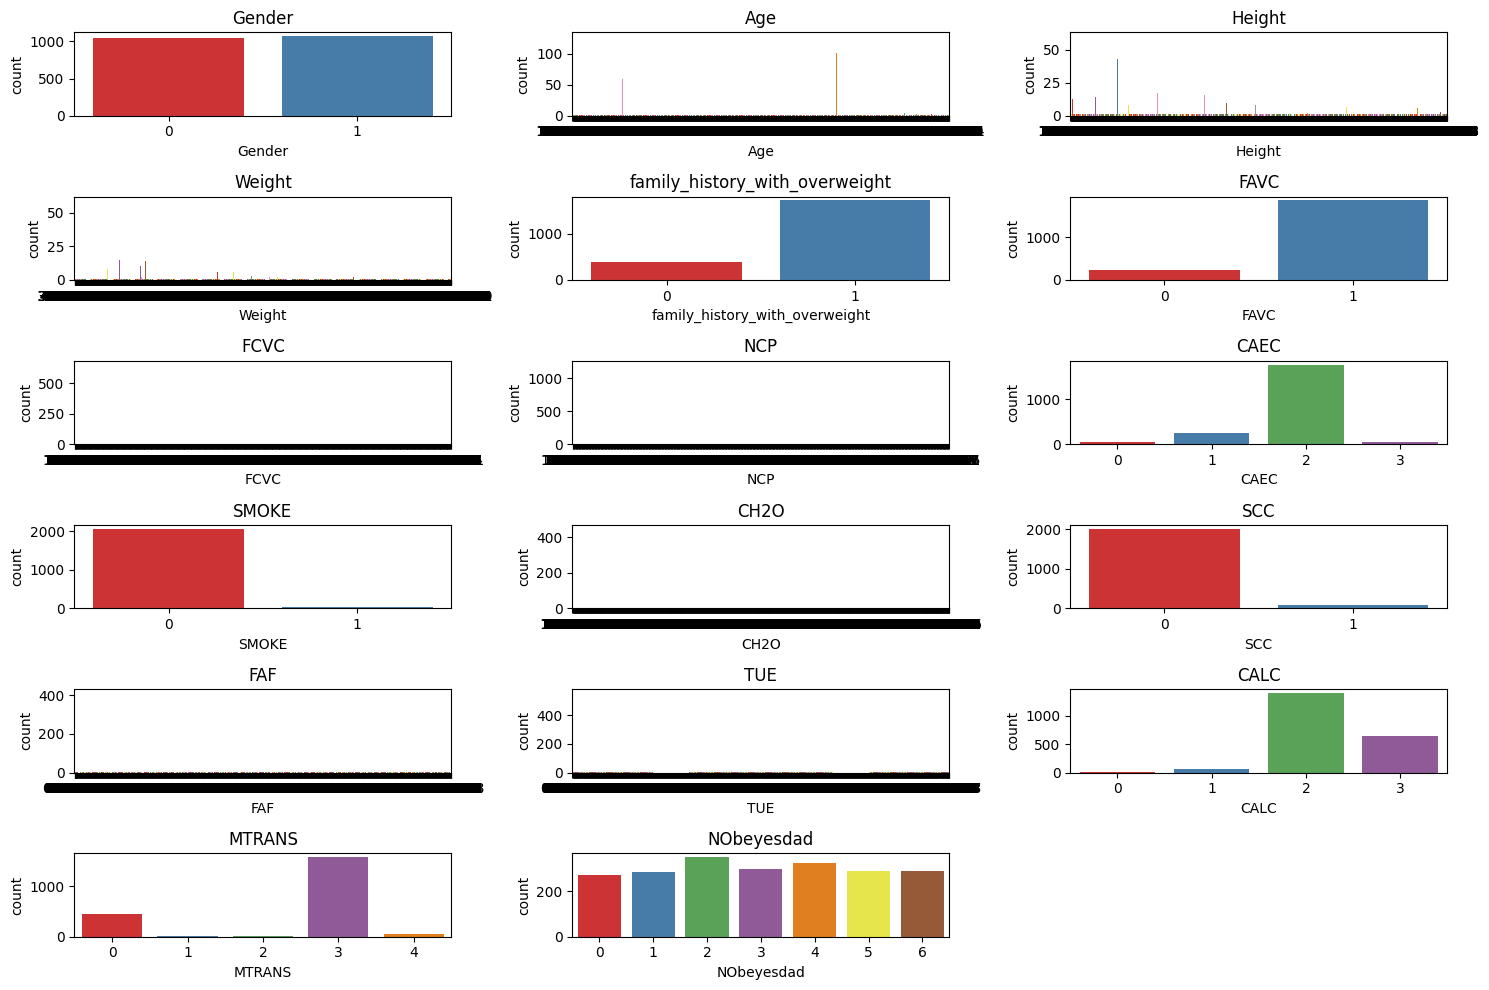

In [73]:
color_palette = sns.color_palette("Set1", len(df.columns))

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot((len(df.columns)//3)+1, 3, i)
    sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(column)

plt.tight_layout()
plt.show()

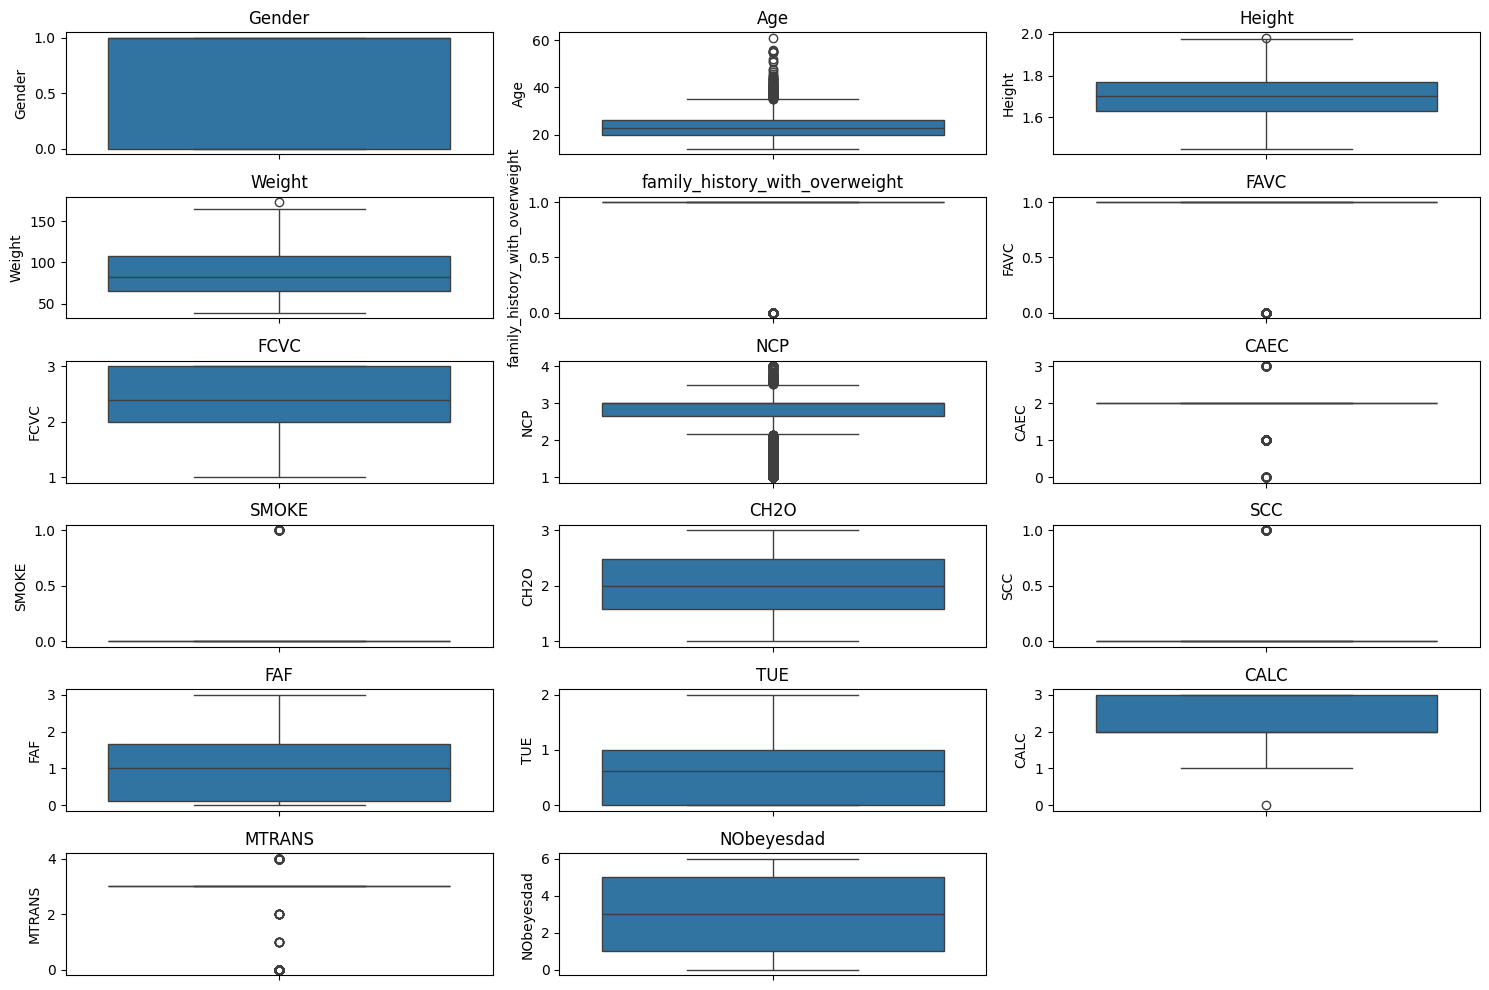

In [74]:
# Select ALL numeric columns (includes newly converted bool + category)
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [77]:
cols = ['Weight', 'Height']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

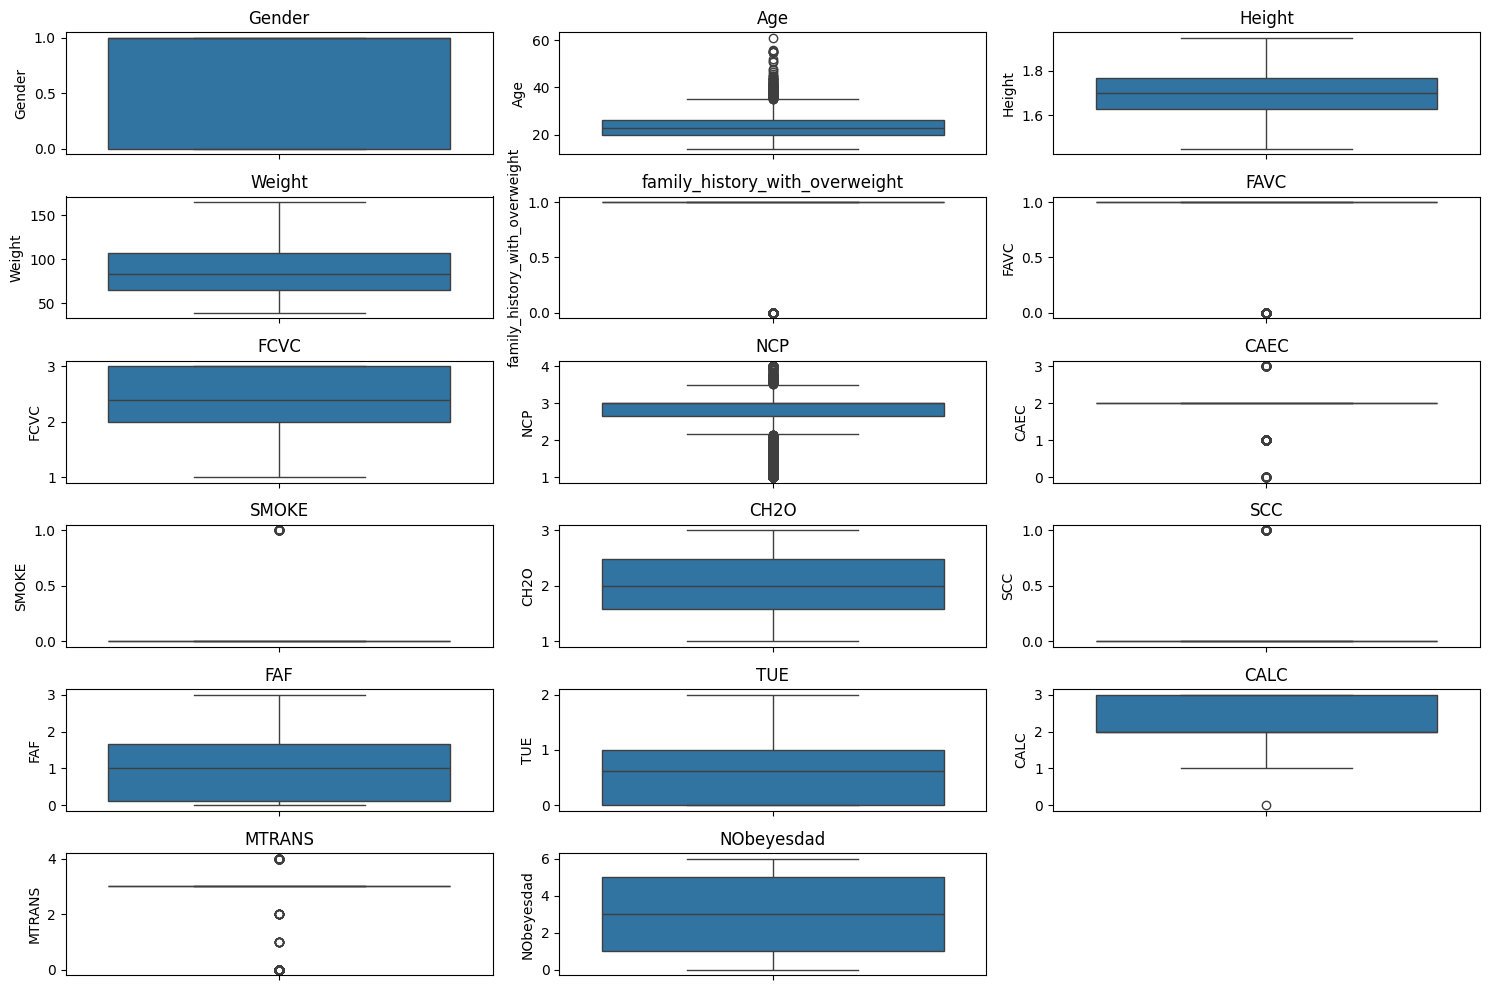

In [78]:
# Select ALL numeric columns (includes newly converted bool + category)
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [79]:
df_train = df[num_cols]

## K-Means Clustering

In [80]:
wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [509112.73035228485]
silhoutte score for n_clusters = 2 is 0.5633761792221659
wcss score for n_cluster = 3 is [509112.73035228485, 285898.5195199099]
silhoutte score for n_clusters = 3 is 0.495534779370158
wcss score for n_cluster = 4 is [509112.73035228485, 285898.5195199099, 201875.61351306297]
silhoutte score for n_clusters = 4 is 0.46657411055784515
wcss score for n_cluster = 5 is [509112.73035228485, 285898.5195199099, 201875.61351306297, 163868.6841899989]
silhoutte score for n_clusters = 5 is 0.41884983528759456
wcss score for n_cluster = 6 is [509112.73035228485, 285898.5195199099, 201875.61351306297, 163868.6841899989, 130188.33349472217]
silhoutte score for n_clusters = 6 is 0.44573558125204926
wcss score for n_cluster = 7 is [509112.73035228485, 285898.5195199099, 201875.61351306297, 163868.6841899989, 130188.33349472217, 104033.8839292812]
silhoutte score for n_clusters = 7 is 0.4309898099496047
wcss score for n_cluster = 8 is [509112.7303522

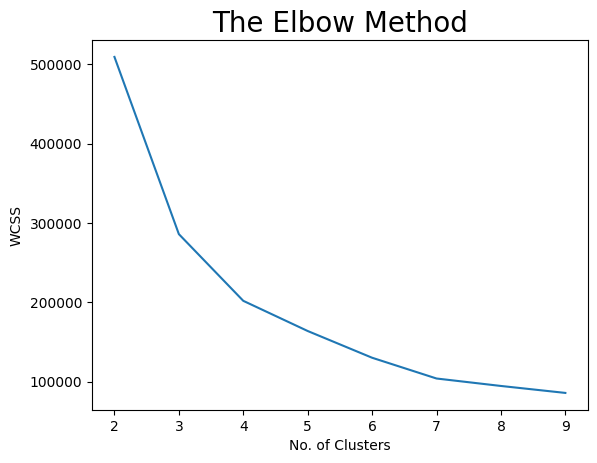

In [81]:
# Visualisasi Elbow Score
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

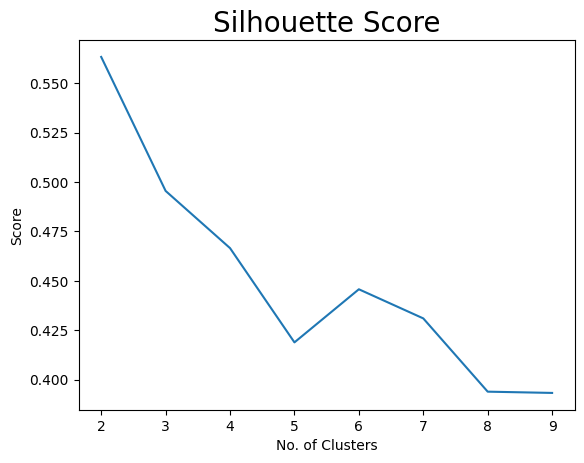

In [82]:
# Visualisasi Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [83]:
kmeansmodel = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

df_train['Cluster'] = y_kmeans

In [84]:
df_train[df_train['Cluster'] == 0].describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Cluster
count,1286.000000,1286.000000,1286.000000,1286.000000,1286.00000,1286.000000,1286.000000,1286.000000,1286.000000,1286.00000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.0
mean,0.444790,23.573199,1.674990,68.842237,0.70451,0.821151,2.322428,2.608619,1.783048,0.01944,1.943098,0.073095,1.071110,0.667667,2.336703,2.291602,2.823484,0.0
std,0.497136,6.967184,0.091013,14.229117,0.45644,0.383375,0.533309,0.903802,0.565183,0.13812,0.609253,0.260393,0.899749,0.653422,0.558770,1.324903,2.365927,0.0
min,0.000000,14.000000,1.450000,39.000000,0.00000,0.000000,1.000000,1.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,19.000000,1.605501,56.276224,0.00000,1.000000,2.000000,2.008204,2.000000,0.00000,1.510309,0.000000,0.130031,0.000000,2.000000,2.000000,1.000000,0.0
50%,0.000000,21.085569,1.675529,70.000000,1.00000,1.000000,2.061422,3.000000,2.000000,0.00000,2.000000,0.000000,1.000000,0.641145,2.000000,3.000000,2.000000,0.0
75%,1.000000,24.261370,1.740000,80.538174,1.00000,1.000000,2.941123,3.000000,2.000000,0.00000,2.197400,0.000000,2.000000,1.000000,3.000000,3.000000,5.000000,0.0
max,1.000000,61.000000,1.930000,91.499683,1.00000,1.000000,3.000000,4.000000,3.000000,1.00000,3.000000,1.000000,3.000000,2.000000,3.000000,4.000000,6.000000,0.0


In [85]:
df_train[df_train['Cluster'] == 1].describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Cluster
count,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.0
mean,0.599757,25.486950,1.742552,114.152492,0.993917,0.981752,2.570508,2.804959,1.981752,0.023114,2.107163,0.002433,0.914262,0.641284,2.163017,2.478102,3.317518,1.0
std,0.490246,5.019657,0.080005,13.408302,0.077802,0.133929,0.499067,0.503321,0.187054,0.150358,0.604798,0.049296,0.758995,0.532759,0.419029,1.148587,0.937854,0.0
min,0.000000,17.000000,1.560000,91.495718,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.0
25%,0.000000,21.697106,1.674682,104.790671,1.000000,1.000000,2.031610,3.000000,2.000000,0.000000,1.663950,0.000000,0.112199,0.167402,2.000000,3.000000,3.000000,1.0
50%,1.000000,25.496168,1.752972,111.941263,1.000000,1.000000,2.871453,3.000000,2.000000,0.000000,2.137210,0.000000,0.975904,0.617066,2.000000,3.000000,3.000000,1.0
75%,1.000000,26.947124,1.795956,120.994169,1.000000,1.000000,3.000000,3.000000,2.000000,0.000000,2.627254,0.000000,1.484860,0.927822,2.000000,3.000000,4.000000,1.0
max,1.000000,41.000000,1.947406,165.057269,1.000000,1.000000,3.000000,4.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,3.000000,4.000000,6.000000,1.0


In [86]:
cluster_summary = df_train.groupby('Cluster').mean()
cluster_summary

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Cluster,,,,,,,,,,,,,,,,,
0,0.444790,23.573199,1.674990,68.842237,0.704510,0.821151,2.322428,2.608619,1.783048,0.019440,1.943098,0.073095,1.071110,0.667667,2.336703,2.291602,2.823484
1,0.599757,25.486950,1.742552,114.152492,0.993917,0.981752,2.570508,2.804959,1.981752,0.023114,2.107163,0.002433,0.914262,0.641284,2.163017,2.478102,3.317518


## Hierarchical (Agglomerative) Clustering

In [87]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']
silhouette_scores_linkage = {method: [] for method in linkage_methods}

for linkage_method in linkage_methods:
    print('Linkage: ', linkage_method)
    for i in range(2, 10):
        model = AgglomerativeClustering(n_clusters=i, linkage=linkage_method)
        labels = model.fit_predict(df_train)
        score = silhouette_score(df_train, labels)
        silhouette_scores_linkage[linkage_method].append(score)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(score))
    print("\n##########################\n")

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.5638329912400583
silhoutte score for n_clusters = 3 is 0.4550895449249339
silhoutte score for n_clusters = 4 is 0.4473259886744042
silhoutte score for n_clusters = 5 is 0.4065127050634058
silhoutte score for n_clusters = 6 is 0.3747873217039294
silhoutte score for n_clusters = 7 is 0.37961257524900716
silhoutte score for n_clusters = 8 is 0.3671058790682803
silhoutte score for n_clusters = 9 is 0.3762643221599643

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.39027142873064447
silhoutte score for n_clusters = 3 is 0.3913824874771097
silhoutte score for n_clusters = 4 is 0.44599896970350517
silhoutte score for n_clusters = 5 is 0.4421730639702752
silhoutte score for n_clusters = 6 is 0.4228009057128749
silhoutte score for n_clusters = 7 is 0.4138828381010868
silhoutte score for n_clusters = 8 is 0.4018691629769554
silhoutte score for n_clusters = 9 is 0.3910819058354135

#####################

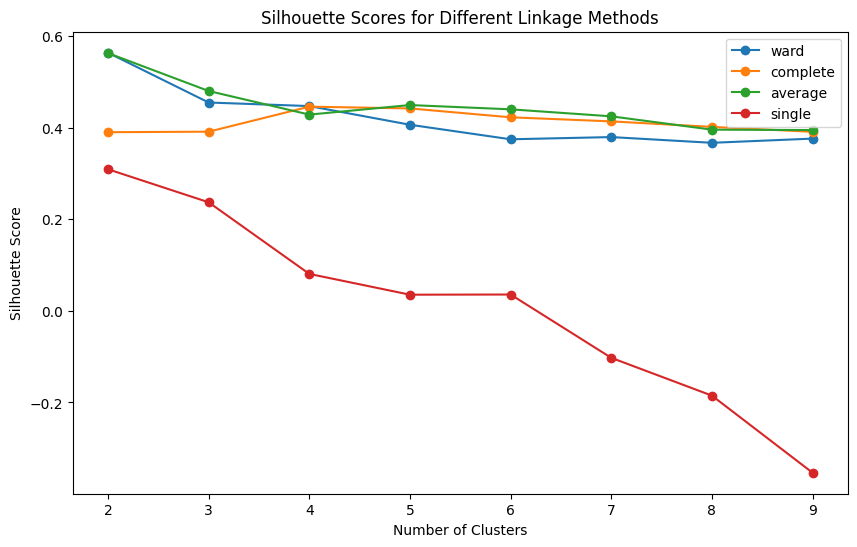

In [88]:
plt.figure(figsize=(10, 6))
for method, scores in silhouette_scores_linkage.items():
    plt.plot(range(2, 10), scores, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Linkage Methods')
plt.legend()
plt.show()

In [89]:
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='average')
df_train_with_labels = df_train.copy()
df_train_with_labels['Cluster'] = agg_clustering.fit_predict(df_train)
cluster_summary = df_train_with_labels.groupby('Cluster').mean()
print(cluster_summary)

           Gender        Age    Height      Weight  \
Cluster                                              
0        0.445988  23.636130  1.676375   69.031473   
1        0.599754  25.410077  1.741174  114.408468   

         family_history_with_overweight      FAVC      FCVC       NCP  \
Cluster                                                                 
0                              0.706790  0.822531  2.321247  2.608155   
1                              0.993842  0.981527  2.575448  2.808118   

             CAEC     SMOKE      CH2O       SCC       FAF       TUE      CALC  \
Cluster                                                                         
0        1.783951  0.019290  1.942785  0.072531  1.070472  0.666465  2.331790   
1        1.982759  0.023399  2.109683  0.002463  0.913349  0.642878  2.168719   

           MTRANS  NObeyesdad  
Cluster                        
0        2.293210    2.847994  
1        2.477833    3.284483  


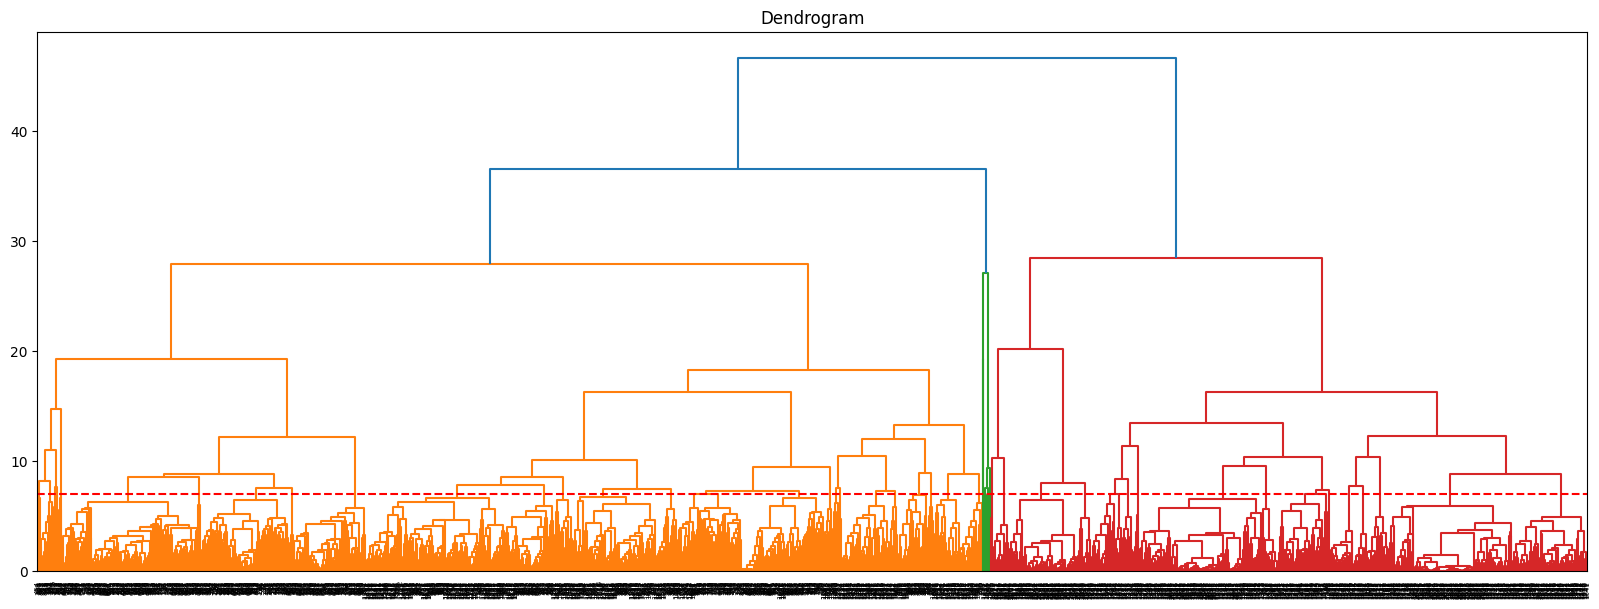

In [90]:
linked = sch.linkage(df_train, method='average')
plt.figure(figsize=(20, 7))
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.axhline(y=7, color='r', linestyle='--')
plt.title('Dendrogram')
plt.show()

# Selected Features

In [91]:
df = pd.read_csv('./ObesityDataSet_raw_and_data_sinthetic.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [93]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [94]:
df.columns = df.columns.str.strip()

# Convert True/False boolean columns to 1/0
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# Convert categorical/object columns to numeric codes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[cat_cols] = df[cat_cols].apply(lambda col: pd.Categorical(col).codes)

print(df.dtypes)
print(df.head())

Gender                               int8
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight       int8
FAVC                                 int8
FCVC                              float64
NCP                               float64
CAEC                                 int8
SMOKE                                int8
CH2O                              float64
SCC                                  int8
FAF                               float64
TUE                               float64
CALC                                 int8
MTRANS                               int8
NObeyesdad                           int8
dtype: object
   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0    

/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/3667412469.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [95]:
selected_columns = ['Weight'] 
df = df[selected_columns]
df

,Weight
0,64.000000
1,56.000000
2,77.000000
3,87.000000
4,89.800000
...,...
2106,131.408528
2107,133.742943
2108,133.689352
2109,133.346641


/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: 
The palette list has fewer values (1) than needed (1525) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=column, palette=color_palette)


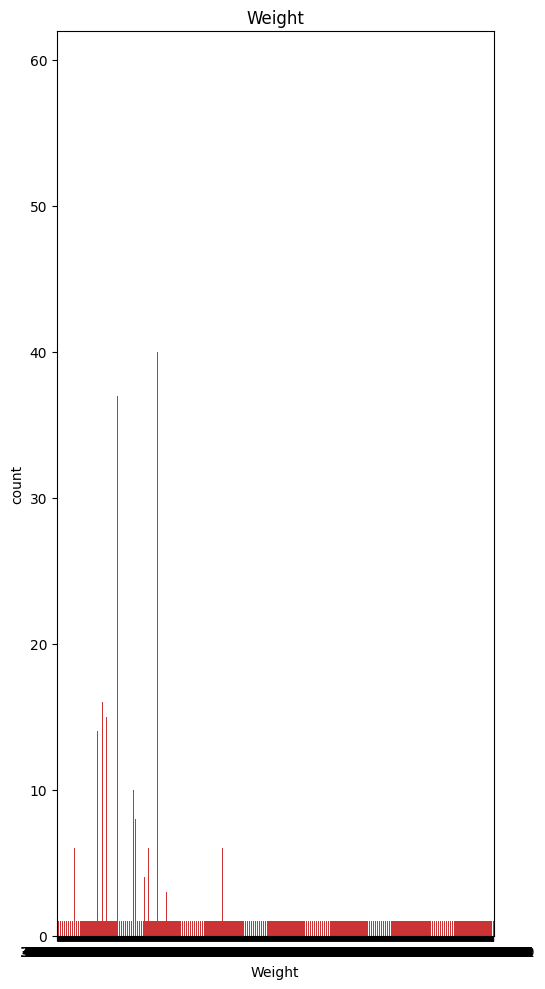

In [96]:
color_palette = sns.color_palette("Set1", len(df.columns))

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot((len(df.columns)//3)+1, 3, i)
    sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(column)

plt.tight_layout()
plt.show()

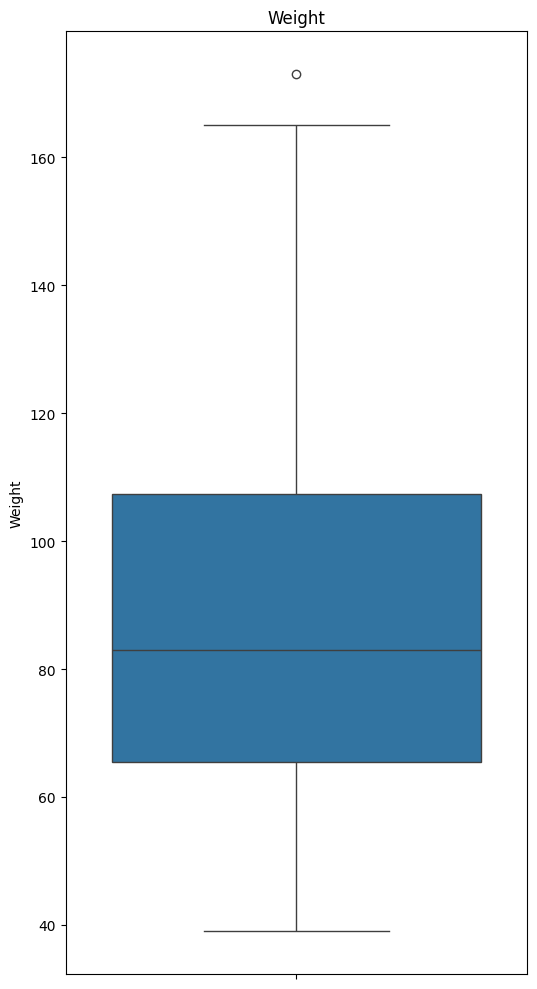

In [97]:
# Select ALL numeric columns (includes newly converted bool + category)
plt.figure(figsize=(15, 10))
for i, col in enumerate(df, 1):
    plt.subplot((len(df.columns) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [98]:
cols = ['Weight']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

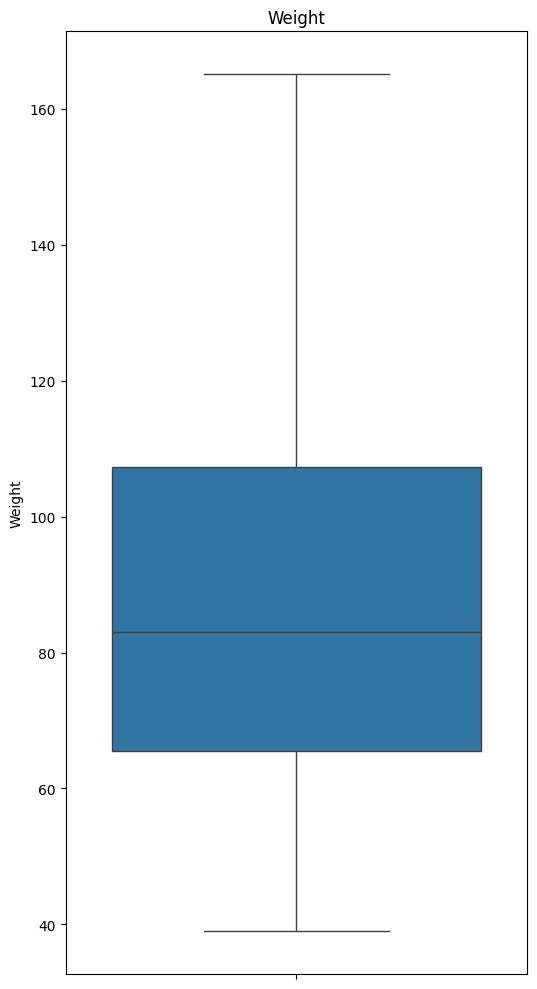

In [99]:
# Select ALL numeric columns (includes newly converted bool + category)
plt.figure(figsize=(15, 10))
for i, col in enumerate(df, 1):
    plt.subplot((len(df.columns) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

## K-Means Clustering

In [100]:
df_train = df

wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [407930.6427797008]
silhoutte score for n_clusters = 2 is 0.625654346444445
wcss score for n_cluster = 3 is [407930.6427797008, 195021.34535134735]
silhoutte score for n_clusters = 3 is 0.5974524341634941
wcss score for n_cluster = 4 is [407930.6427797008, 195021.34535134735, 111422.9458671885]
silhoutte score for n_clusters = 4 is 0.5887044350212762
wcss score for n_cluster = 5 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166]
silhoutte score for n_clusters = 5 is 0.5775937817485416
wcss score for n_cluster = 6 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166, 51097.06677143114]
silhoutte score for n_clusters = 6 is 0.5837804065509969
wcss score for n_cluster = 7 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166, 51097.06677143114, 40031.38398566068]
silhoutte score for n_clusters = 7 is 0.5647405432894875
wcss score for n_cluster = 8 is [407930.6427797008, 19502

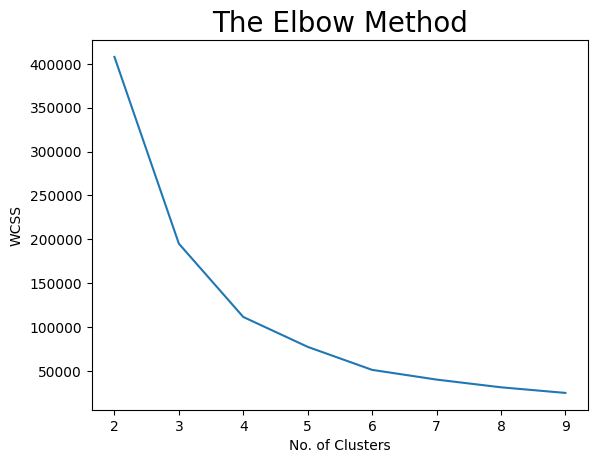

In [101]:
# Visualisasi Elbow Score
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

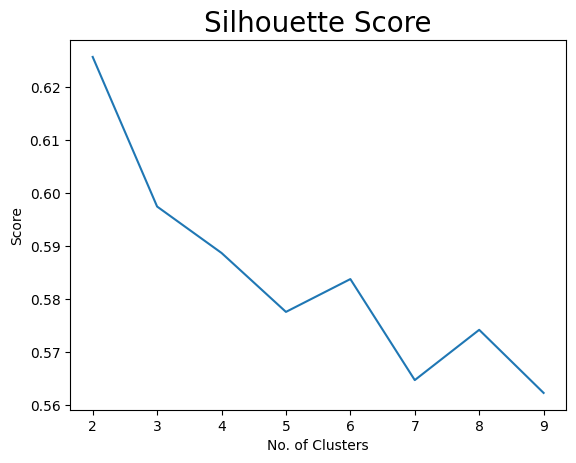

In [102]:
# Visualisasi Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [103]:
kmeansmodel = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

df_train['Cluster'] = y_kmeans

In [104]:
df_train[df_train['Cluster'] == 0].describe()

,Weight,Cluster
count,823.000000,823.0
mean,114.201162,0.0
std,13.384033,0.0
min,91.630257,0.0
25%,104.799160,0.0
50%,111.945588,0.0
75%,120.996328,0.0
max,165.057269,0.0


In [105]:
df_train[df_train['Cluster'] == 1].describe()

,Weight,Cluster
count,1287.000000,1287.0
mean,68.859839,1.0
std,14.237593,0.0
min,39.000000,1.0
25%,56.286489,1.0
50%,70.000000,1.0
75%,80.546033,1.0
max,91.499683,1.0


In [106]:
cluster_summary = df_train.groupby('Cluster').mean()
cluster_summary

,Weight
Cluster,
0,114.201162
1,68.859839


In [107]:
trace0 = go.Scatter(
    x=df_train[df_train['Cluster'] == 0]['Weight'],
    y=[0]*len(df_train[df_train['Cluster'] == 0]),  # all points at y=0
    mode='markers',
    marker=dict(size=10, color='red', opacity=0.8),
    name='Cluster 0'
)

# Trace for Cluster 1
trace1 = go.Scatter(
    x=df_train[df_train['Cluster'] == 1]['Weight'],
    y=[0]*len(df_train[df_train['Cluster'] == 1]),
    mode='markers',
    marker=dict(size=10, color='blue', opacity=0.8),
    name='Cluster 1'
)

# Centroids (y set to 0 as well)
centroids = go.Scatter(
    x=kmeansmodel.cluster_centers_[:, 0],  # Weight
    y=[0]*len(kmeansmodel.cluster_centers_[:, 0]),  # y=0
    mode='markers',
    marker=dict(size=15, color='black', symbol='x', opacity=1),
    name='Centroids'
)

# Layout
layout = go.Layout(
    title='KMeans Clustering (Weight Only)',
    xaxis_title='Weight',
    yaxis=dict(visible=False),  # hide y-axis entirely
    showlegend=True
)

# Plot
fig = go.Figure(data=[trace0, trace1, centroids], layout=layout)
fig.show()

## Hierarchical (Agglomerative) Clustering

In [108]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']
silhouette_scores_linkage = {method: [] for method in linkage_methods}

for linkage_method in linkage_methods:
    print('Linkage: ', linkage_method)
    for i in range(2, 10):
        model = AgglomerativeClustering(n_clusters=i, linkage=linkage_method)
        labels = model.fit_predict(df_train)
        score = silhouette_score(df_train, labels)
        silhouette_scores_linkage[linkage_method].append(score)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(score))
    print("\n##########################\n")

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.6258470173312455
silhoutte score for n_clusters = 3 is 0.5137507618822748
silhoutte score for n_clusters = 4 is 0.5258004121484549
silhoutte score for n_clusters = 5 is 0.5345618510662511
silhoutte score for n_clusters = 6 is 0.5442049558662432
silhoutte score for n_clusters = 7 is 0.545936149847563
silhoutte score for n_clusters = 8 is 0.5480081623285107
silhoutte score for n_clusters = 9 is 0.5569989125095037

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.601590261192158
silhoutte score for n_clusters = 3 is 0.5568522688385373
silhoutte score for n_clusters = 4 is 0.5662265729682388
silhoutte score for n_clusters = 5 is 0.5569302259680019
silhoutte score for n_clusters = 6 is 0.5266706794135083
silhoutte score for n_clusters = 7 is 0.5140895981565046
silhoutte score for n_clusters = 8 is 0.4866384091005294
silhoutte score for n_clusters = 9 is 0.4866605528498628

##########################

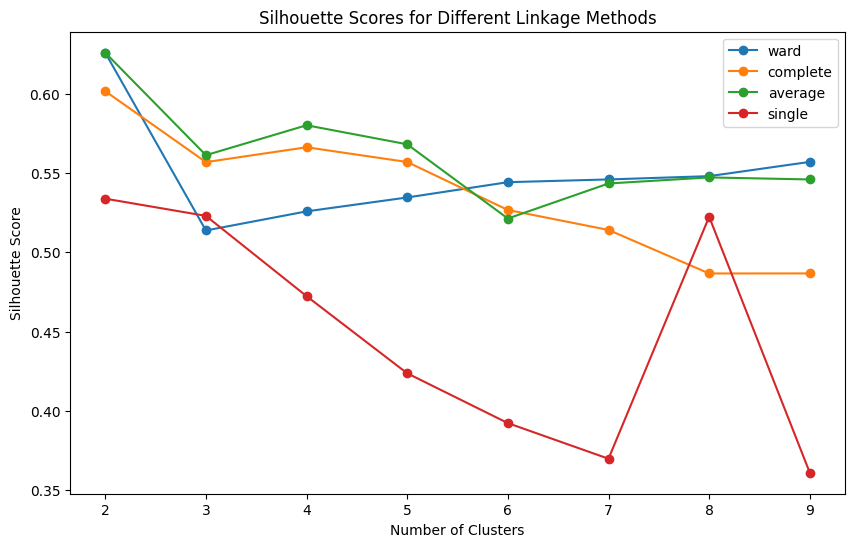

In [109]:
plt.figure(figsize=(10, 6))
for method, scores in silhouette_scores_linkage.items():
    plt.plot(range(2, 10), scores, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Linkage Methods')
plt.legend()
plt.show()

In [110]:
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='average')
df_train_with_labels = df_train.copy()
df_train_with_labels['Cluster'] = agg_clustering.fit_predict(df_train)
cluster_summary = df_train_with_labels.groupby('Cluster').mean()
print(cluster_summary)

             Weight
Cluster            
0        114.201162
1         68.859839


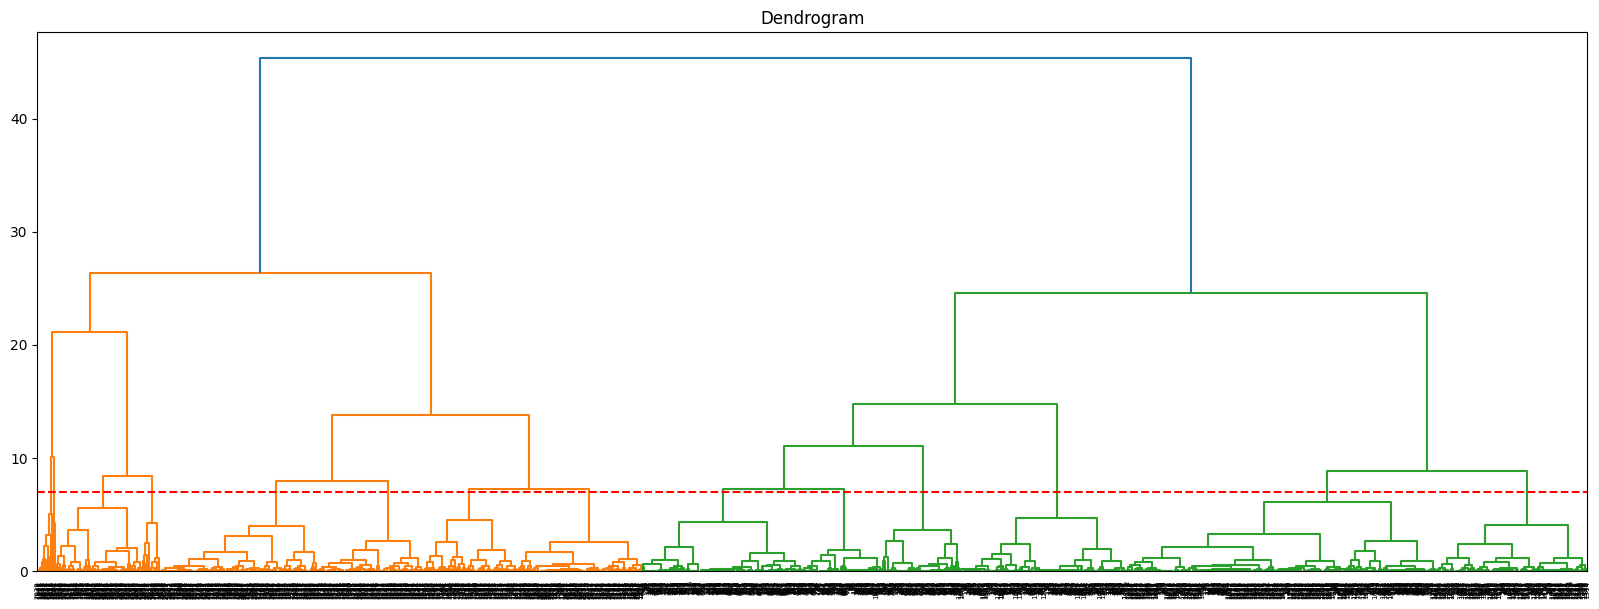

In [111]:
linked = sch.linkage(df_train, method='average')
plt.figure(figsize=(20, 7))
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.axhline(y=7, color='r', linestyle='--')
plt.title('Dendrogram')
plt.show()